# Sentry: YOLOv8 Weapon Detection Training

This notebook fine-tunes YOLOv8-Nano on the Weapon Detection dataset for real-time threat detection.

**Classes:** `gun`, `knife`, `person_with_mask`

**Dataset:** Roboflow Universe (weapon-detection-pgqnr v8)


## 1. Environment Setup

In [1]:
!nvidia-smi

Wed Jan 14 16:48:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics>=8.0.0 --quiet
!pip install opencv-python>=4.8.0 pandas>=2.0.0 matplotlib>=3.7.0 --quiet

In [3]:
# Import libraries
import os
import glob
import random
import zipfile
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches

from ultralytics import YOLO

print("All imports successful!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All imports successful!


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
!unzip -q "/content/Weapon-Detection.v8-adi_v2.yolov8.zip" -d dataset

---
## 2. Dataset Preparation

In [9]:
 # Display data.yaml contents
DATA_YAML = "/content/dataset/data.yaml"

print("=" * 50)
print("DATA.YAML CONTENTS")
print("=" * 50)
with open(DATA_YAML, 'r') as f:
    print(f.read())

DATA.YAML CONTENTS
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['gun', 'knife', 'person_with_mask']

roboflow:
  workspace: weapon-rcjrw
  project: weapon-detection-pgqnr
  version: 8
  license: CC BY 4.0
  url: https://universe.roboflow.com/weapon-rcjrw/weapon-detection-pgqnr/dataset/8


In [10]:
  # Verify dataset structure
import os

DATA_DIR = "/content/dataset"

print("Dataset Structure:")
print("=" * 50)
for split in ['train', 'valid', 'test']:
    split_path = os.path.join(DATA_DIR, split)
    if os.path.exists(split_path):
        images = len(os.listdir(os.path.join(split_path, 'images')))
        labels = len(os.listdir(os.path.join(split_path, 'labels')))
        print(f"{split:8} -> {images:5} images, {labels:5} labels")

Dataset Structure:
train    -> 22746 images, 22746 labels
valid    ->  1997 images,  1997 labels
test     ->   973 images,   973 labels


In [11]:
import yaml

# Read and update paths
with open(DATA_YAML, 'r') as f:
    data_config = yaml.safe_load(f)

# Update to absolute paths
data_config['train'] = '/content/dataset/train/images'
data_config['val'] = '/content/dataset/valid/images'
data_config['test'] = '/content/dataset/test/images'

# Save updated config
with open(DATA_YAML, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("Updated data.yaml:")
print(yaml.dump(data_config, default_flow_style=False))

Updated data.yaml:
names:
- gun
- knife
- person_with_mask
nc: 3
roboflow:
  license: CC BY 4.0
  project: weapon-detection-pgqnr
  url: https://universe.roboflow.com/weapon-rcjrw/weapon-detection-pgqnr/dataset/8
  version: 8
  workspace: weapon-rcjrw
test: /content/dataset/test/images
train: /content/dataset/train/images
val: /content/dataset/valid/images



---
## 3. Data Audit

In [12]:
# Get class names from data.yaml
CLASS_NAMES = data_config.get('names', [])
if isinstance(CLASS_NAMES, dict):
    CLASS_NAMES = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]

print(f"Classes: {CLASS_NAMES}")
print(f"Number of classes: {len(CLASS_NAMES)}")

Classes: ['gun', 'knife', 'person_with_mask']
Number of classes: 3


In [13]:
# Class Distribution Analysis
def count_class_instances(labels_dir):
    """Count instances of each class in label files."""
    class_counts = Counter()
    label_files = glob.glob(os.path.join(labels_dir, "*.txt"))

    for label_file in label_files:
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    class_id = int(parts[0])
                    class_counts[class_id] += 1

    return class_counts, len(label_files)

# Define paths directly (based on extracted structure)
TRAIN_LABELS_DIR = os.path.join(DATA_DIR, 'train', 'labels')
TRAIN_IMAGES_DIR = os.path.join(DATA_DIR, 'train', 'images')
VAL_LABELS_DIR = os.path.join(DATA_DIR, 'valid', 'labels')
VAL_IMAGES_DIR = os.path.join(DATA_DIR, 'valid', 'images')
TEST_LABELS_DIR = os.path.join(DATA_DIR, 'test', 'labels')
TEST_IMAGES_DIR = os.path.join(DATA_DIR, 'test', 'images')

print("=" * 50)
print("CLASS DISTRIBUTION ANALYSIS")
print("=" * 50)

total_counts = Counter()

for split_name, labels_dir in [("Train", TRAIN_LABELS_DIR),
                                ("Validation", VAL_LABELS_DIR),
                                ("Test", TEST_LABELS_DIR)]:
    if os.path.exists(labels_dir):
        counts, num_files = count_class_instances(labels_dir)
        total_counts.update(counts)
        print(f"\n{split_name} Set ({num_files} images):")
        for class_id, count in sorted(counts.items()):
            class_name = CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else f"class_{class_id}"
            print(f"  {class_name}: {count} instances")

print(f"\n{'='*50}")
print("TOTAL:")
for class_id, count in sorted(total_counts.items()):
    class_name = CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else f"class_{class_id}"
    print(f"  {class_name}: {count} instances")
print(f"Total annotations: {sum(total_counts.values())}")

CLASS DISTRIBUTION ANALYSIS

Train Set (22746 images):
  gun: 14439 instances
  knife: 9447 instances
  person_with_mask: 1341 instances

Validation Set (1997 images):
  gun: 1327 instances
  knife: 764 instances
  person_with_mask: 90 instances

Test Set (973 images):
  gun: 659 instances
  knife: 376 instances
  person_with_mask: 49 instances

TOTAL:
  gun: 16425 instances
  knife: 10587 instances
  person_with_mask: 1480 instances
Total annotations: 28492


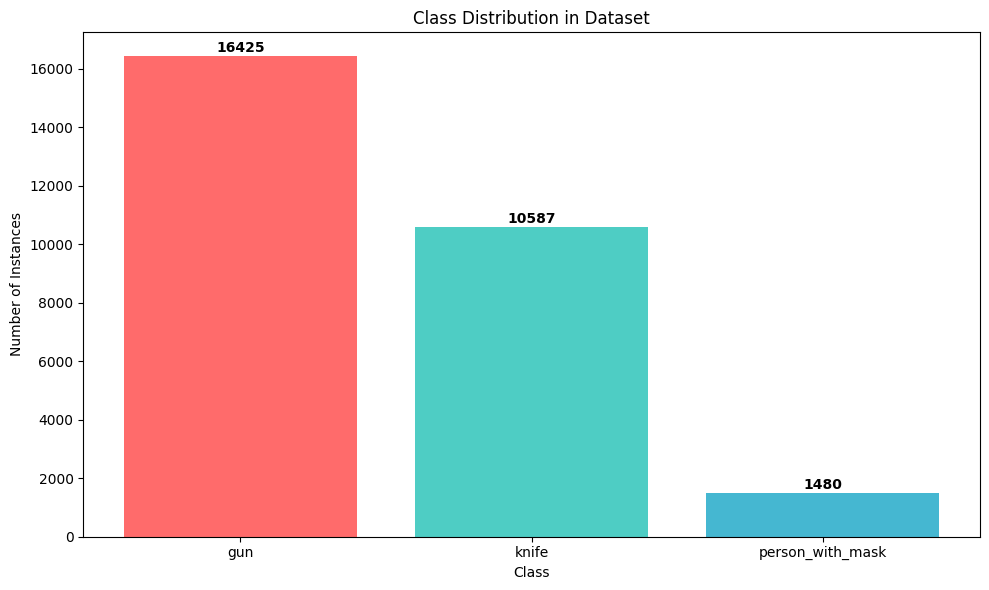

In [14]:
# Visualize class distribution
labels = [CLASS_NAMES[i] if i < len(CLASS_NAMES) else f"class_{i}"
          for i in sorted(total_counts.keys())]
values = [total_counts[i] for i in sorted(total_counts.keys())]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'][:len(labels)])
plt.xlabel('Class')
plt.ylabel('Number of Instances')
plt.title('Class Distribution in Dataset')

# Add value labels on bars
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(val), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

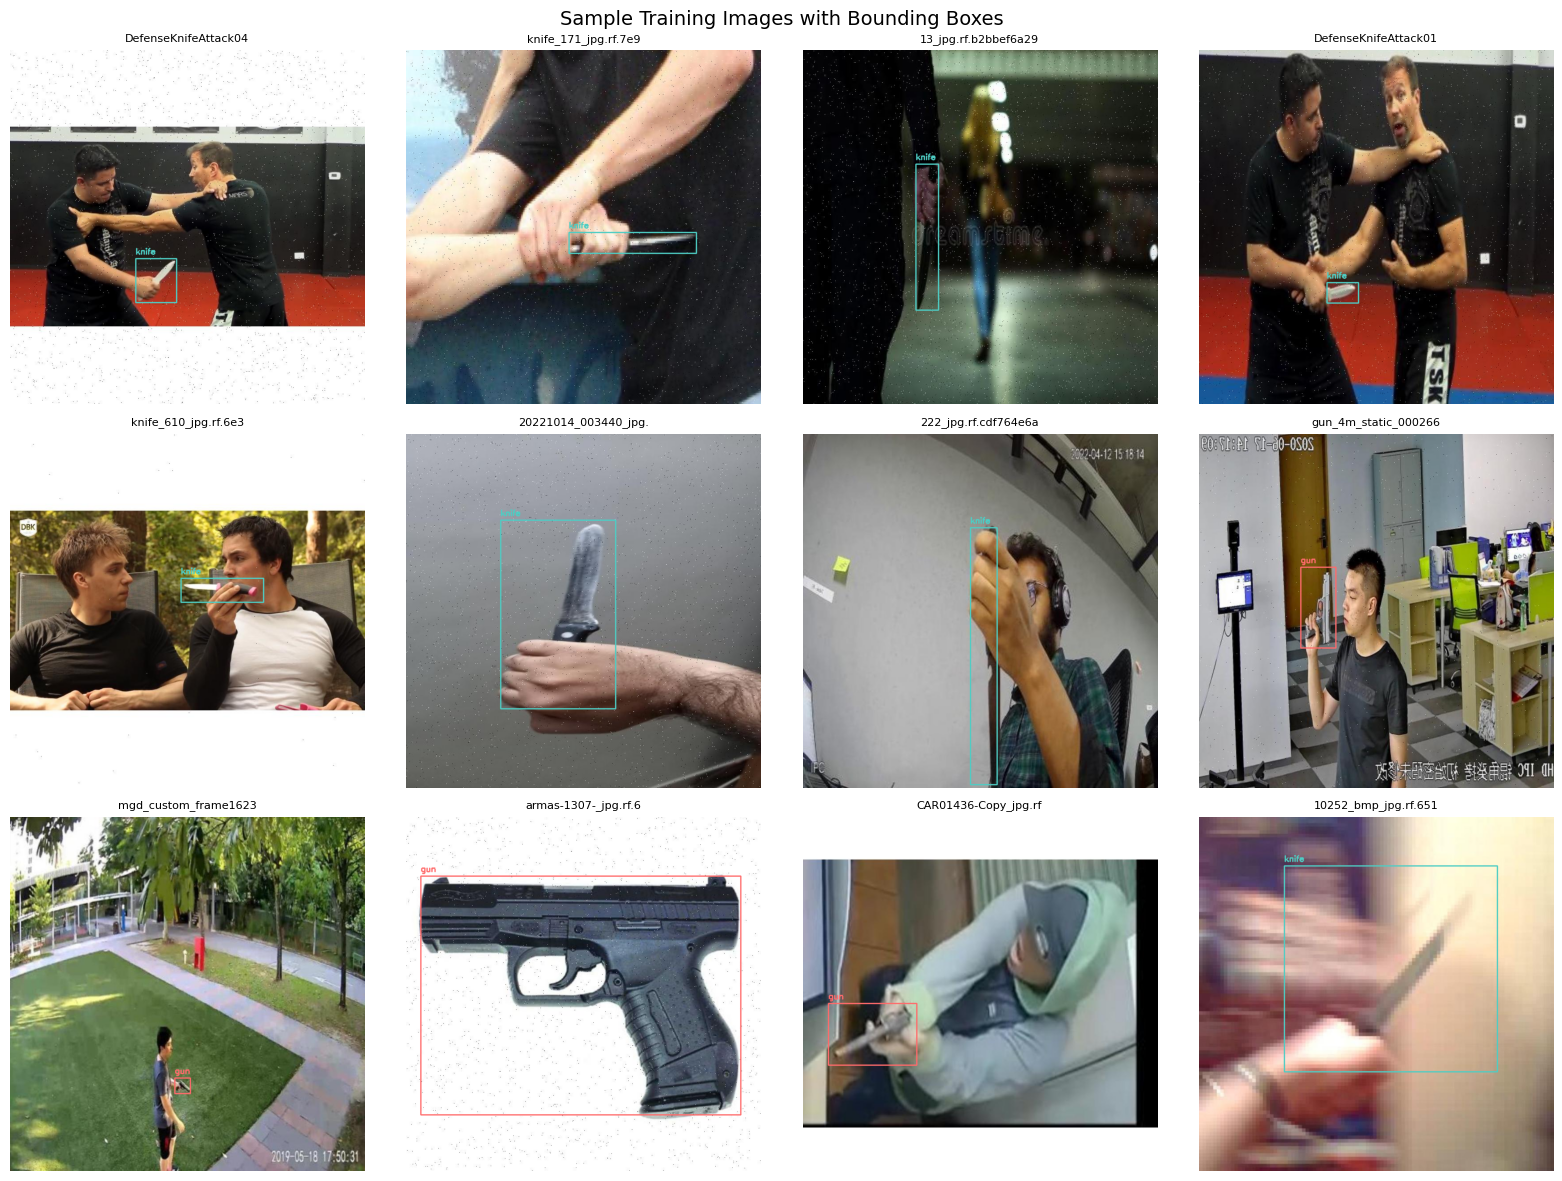

In [15]:
# Visual Inspection - Display sample images with bounding boxes
def draw_bboxes(image_path, label_path, class_names):
    """Draw bounding boxes on image."""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    colors = [(255, 107, 107), (78, 205, 196), (69, 183, 209), (150, 206, 180)]

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    x_center, y_center, bbox_w, bbox_h = map(float, parts[1:5])

                    # Convert YOLO format to pixel coordinates
                    x1 = int((x_center - bbox_w/2) * w)
                    y1 = int((y_center - bbox_h/2) * h)
                    x2 = int((x_center + bbox_w/2) * w)
                    y2 = int((y_center + bbox_h/2) * h)

                    color = colors[class_id % len(colors)]
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

                    label = class_names[class_id] if class_id < len(class_names) else f"class_{class_id}"
                    cv2.putText(img, label, (x1, y1-10),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    return img

# Get sample images from training set
if os.path.exists(TRAIN_IMAGES_DIR):
    image_files = glob.glob(os.path.join(TRAIN_IMAGES_DIR, "*.[jp][pn][g]*"))
    sample_images = random.sample(image_files, min(12, len(image_files)))

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()

    for idx, img_path in enumerate(sample_images):
        # Get corresponding label file
        img_name = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(TRAIN_LABELS_DIR, img_name + '.txt')

        img_with_boxes = draw_bboxes(img_path, label_path, CLASS_NAMES)
        axes[idx].imshow(img_with_boxes)
        axes[idx].set_title(os.path.basename(img_path)[:20], fontsize=8)
        axes[idx].axis('off')

    plt.suptitle('Sample Training Images with Bounding Boxes', fontsize=14)
    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150)
    plt.show()
else:
    print(f"Training images directory not found: {TRAIN_IMAGES_DIR}")

In [16]:
# Resolution Check
def check_image_resolutions(images_dir, sample_size=100):
    """Check image resolutions."""
    image_files = glob.glob(os.path.join(images_dir, "*.[jp][pn][g]*"))
    sample_files = random.sample(image_files, min(sample_size, len(image_files)))

    resolutions = []
    for img_path in sample_files:
        img = cv2.imread(img_path)
        if img is not None:
            h, w = img.shape[:2]
            resolutions.append((w, h))

    return resolutions

if os.path.exists(TRAIN_IMAGES_DIR):
    resolutions = check_image_resolutions(TRAIN_IMAGES_DIR)
    resolution_counts = Counter(resolutions)

    print("=" * 50)
    print("IMAGE RESOLUTION CHECK")
    print("=" * 50)
    print(f"Sampled {len(resolutions)} images")
    print("\nResolution distribution:")
    for res, count in resolution_counts.most_common():
        print(f"  {res[0]}x{res[1]}: {count} images ({count/len(resolutions)*100:.1f}%)")
else:
    print(f"Training images directory not found: {TRAIN_IMAGES_DIR}")

IMAGE RESOLUTION CHECK
Sampled 100 images

Resolution distribution:
  800x800: 100 images (100.0%)


---
## 4. Model Training

In [17]:
# Initialize YOLOv8-Nano model
model = YOLO('yolov8n.pt')  # Nano variant for speed
print("Model loaded successfully!")
print(f"Model type: YOLOv8-Nano")

Model loaded successfully!
Model type: YOLOv8-Nano


In [18]:
# Training configuration
TRAINING_CONFIG = {
    'data': DATA_YAML,
    'epochs': 50,
    'patience': 10,
    'imgsz': 640,
    'batch': 16,
    'project': '/content/runs',
    'name': 'sentry_phase1',
    'exist_ok': True,
    'pretrained': True,
    'optimizer': 'auto',
    'verbose': True,
    'seed': 42,
    'deterministic': True,
    'plots': True,
    'save': True,
    'save_period': -1,
}

print("Training Configuration:")
for key, value in TRAINING_CONFIG.items():
    print(f"  {key}: {value}")

Training Configuration:
  data: /content/dataset/data.yaml
  epochs: 50
  patience: 10
  imgsz: 640
  batch: 16
  project: /content/runs
  name: sentry_phase1
  exist_ok: True
  pretrained: True
  optimizer: auto
  verbose: True
  seed: 42
  deterministic: True
  plots: True
  save: True
  save_period: -1


In [ ]:
# Start training
print("Starting training...")
print("=" * 50)

results = model.train(**TRAINING_CONFIG)

print("=" * 50)
print("Training completed!")

Starting training...
Ultralytics 8.4.0 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sentry_phase1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, per

---
## 5. Evaluation & Validation

In [ ]:
# Load training results
RESULTS_DIR = '/content/runs/sentry_phase1'

# Read results.csv
results_csv = os.path.join(RESULTS_DIR, 'results.csv')
if os.path.exists(results_csv):
    df_results = pd.read_csv(results_csv)
    df_results.columns = df_results.columns.str.strip()  # Clean column names
    print("Training Results Summary:")
    print(df_results.tail(10))
else:
    print(f"Results file not found at {results_csv}")

In [ ]:
# Plot training metrics
if 'df_results' in dir():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Box Loss
    axes[0, 0].plot(df_results['epoch'], df_results['train/box_loss'], label='Train', color='blue')
    if 'val/box_loss' in df_results.columns:
        axes[0, 0].plot(df_results['epoch'], df_results['val/box_loss'], label='Val', color='orange')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Box Loss')
    axes[0, 0].set_title('Box Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Class Loss
    axes[0, 1].plot(df_results['epoch'], df_results['train/cls_loss'], label='Train', color='blue')
    if 'val/cls_loss' in df_results.columns:
        axes[0, 1].plot(df_results['epoch'], df_results['val/cls_loss'], label='Val', color='orange')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Class Loss')
    axes[0, 1].set_title('Classification Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # mAP@50
    if 'metrics/mAP50(B)' in df_results.columns:
        axes[1, 0].plot(df_results['epoch'], df_results['metrics/mAP50(B)'],
                       label='mAP@50', color='green', linewidth=2)
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('mAP@50')
        axes[1, 0].set_title('mAP@50')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].set_ylim(0, 1)

    # mAP@50-95
    if 'metrics/mAP50-95(B)' in df_results.columns:
        axes[1, 1].plot(df_results['epoch'], df_results['metrics/mAP50-95(B)'],
                       label='mAP@50-95', color='red', linewidth=2)
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('mAP@50-95')
        axes[1, 1].set_title('mAP@50-95')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].set_ylim(0, 1)

    plt.suptitle('Training Metrics', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'), dpi=150)
    plt.show()

In [ ]:
# Display final metrics
if 'df_results' in dir():
    final_epoch = df_results.iloc[-1]

    print("=" * 50)
    print("FINAL TRAINING METRICS")
    print("=" * 50)
    print(f"Total Epochs: {int(final_epoch['epoch'])}")
    print(f"\nLoss Metrics:")
    print(f"  Box Loss:   {final_epoch.get('train/box_loss', 'N/A'):.4f}")
    print(f"  Class Loss: {final_epoch.get('train/cls_loss', 'N/A'):.4f}")
    print(f"\nPerformance Metrics:")
    print(f"  mAP@50:     {final_epoch.get('metrics/mAP50(B)', 'N/A'):.4f}")
    print(f"  mAP@50-95:  {final_epoch.get('metrics/mAP50-95(B)', 'N/A'):.4f}")
    print(f"  Precision:  {final_epoch.get('metrics/precision(B)', 'N/A'):.4f}")
    print(f"  Recall:     {final_epoch.get('metrics/recall(B)', 'N/A'):.4f}")

In [ ]:
# Display confusion matrix (generated during training)
confusion_matrix_path = os.path.join(RESULTS_DIR, 'confusion_matrix.png')
if os.path.exists(confusion_matrix_path):
    img = plt.imread(confusion_matrix_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Confusion Matrix')
    plt.show()
else:
    print("Confusion matrix image not found")

In [ ]:
# Load best model for validation
best_model_path = os.path.join(RESULTS_DIR, 'weights', 'best.pt')
if os.path.exists(best_model_path):
    best_model = YOLO(best_model_path)
    print(f"Loaded best model from: {best_model_path}")
else:
    print(f"Best model not found at {best_model_path}")
    best_model = model

In [ ]:
# Run validation on validation set
print("Running validation...")
val_results = best_model.val(data=DATA_YAML, imgsz=640, batch=16, verbose=True)

print("\n" + "=" * 50)
print("VALIDATION RESULTS")
print("=" * 50)
print(f"mAP@50:    {val_results.box.map50:.4f}")
print(f"mAP@50-95: {val_results.box.map:.4f}")

In [ ]:
# Inference test on validation images
if os.path.exists(VAL_IMAGES_DIR):
    val_image_files = glob.glob(os.path.join(VAL_IMAGES_DIR, "*.[jp][pn][g]*"))
    sample_val_images = random.sample(val_image_files, min(8, len(val_image_files)))

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for idx, img_path in enumerate(sample_val_images):
        # Run inference
        results = best_model.predict(img_path, conf=0.25, verbose=False)

        # Get annotated image
        annotated_img = results[0].plot()
        annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

        axes[idx].imshow(annotated_img)
        axes[idx].set_title(os.path.basename(img_path)[:20], fontsize=8)
        axes[idx].axis('off')

    plt.suptitle('Inference Results on Validation Set', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'inference_samples.png'), dpi=150)
    plt.show()
else:
    print(f"Validation images directory not found: {VAL_IMAGES_DIR}")

---
## 6. Export Best Model

In [ ]:
# Copy best model to standard location
import shutil

EXPORT_DIR = '/content/models'
os.makedirs(EXPORT_DIR, exist_ok=True)

export_path = os.path.join(EXPORT_DIR, 'sentry_best.pt')
if os.path.exists(best_model_path):
    shutil.copy(best_model_path, export_path)
    print(f"Best model saved to: {export_path}")
    print(f"Model size: {os.path.getsize(export_path) / (1024*1024):.2f} MB")
else:
    print("Best model not found!")

In [ ]:
# Save to Google Drive (optional)
DRIVE_SAVE_PATH = '/content/drive/MyDrive/Sentry/models'

try:
    os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)
    drive_export_path = os.path.join(DRIVE_SAVE_PATH, 'sentry_best.pt')
    shutil.copy(export_path, drive_export_path)
    print(f"Model also saved to Google Drive: {drive_export_path}")
except Exception as e:
    print(f"Could not save to Google Drive: {e}")
    print("You can manually download the model from /content/models/sentry_best.pt")

In [ ]:
# Download model (alternative to Drive)
from google.colab import files

print("Downloading model file...")
files.download(export_path)

---
## Summary

Training complete! Key outputs:

1. **Best Model**: `/content/models/sentry_best.pt`
2. **Training Logs**: `/content/runs/sentry_phase1/`
3. **Visualizations**: Loss curves, confusion matrix, sample predictions

### Next Steps:
- Download `sentry_best.pt` to your local `models/` directory
- Update `PROJECT_PLAN.md` with the mAP scores achieved
- Proceed to Phase 2: Integration with Streamlit dashboard

In [ ]:
# Final summary
print("\n" + "=" * 60)
print("TRAINING COMPLETE - SUMMARY")
print("=" * 60)
print(f"\nModel: YOLOv8-Nano (fine-tuned)")
print(f"Dataset: Weapon Detection v8")
print(f"Classes: {CLASS_NAMES}")
print(f"\nFinal Metrics:")
if 'val_results' in dir():
    print(f"  mAP@50:    {val_results.box.map50:.4f}")
    print(f"  mAP@50-95: {val_results.box.map:.4f}")
print(f"\nModel saved at: {export_path}")
print("=" * 60)